In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [20]:
def generate_ecm_dataset(num_samples_per_class=1000, sequence_length=500):
    """
    Generates synthetic radar signals with REALISTIC LOW SNR and fading.
    """
    t = np.linspace(0, 1, sequence_length)
    X = []
    y = []
    
    # Class 0: Spot Jamming (Targeted single frequency with heavy noise)
    for _ in range(num_samples_per_class):
        f_j = np.random.uniform(50, 150) 
        amplitude = np.random.uniform(0.3, 1.0) # Signal fading
        noise = np.random.normal(0, 0.8, sequence_length) # Increased noise variance from 0.2 to 0.8
        signal = (amplitude * np.sin(2 * np.pi * f_j * t)) + noise
        X.append(signal)
        y.append(0)
        
    # Class 1: Sweep Jamming (Linear frequency chirp with heavy noise)
    for _ in range(num_samples_per_class):
        f_start = np.random.uniform(20, 80)
        f_end = np.random.uniform(120, 250)
        k = (f_end - f_start) / 1.0 
        amplitude = np.random.uniform(0.3, 1.0)
        noise = np.random.normal(0, 0.8, sequence_length) # Increased noise variance
        signal = (amplitude * np.sin(2 * np.pi * (f_start + 0.5 * k * t) * t)) + noise
        X.append(signal)
        y.append(1)
        
    # Class 2: Barrage Jamming (Wideband white noise overlapping other bands)
    for _ in range(num_samples_per_class):
        # Adjusted variance to occasionally look like background noise of Spot/Sweep
        signal = np.random.normal(0, 1.2, sequence_length) 
        X.append(signal)
        y.append(2)
        
    X = np.array(X)[..., np.newaxis] 
    y = np.array(y)
    
    return X, y

In [21]:
print("Initializing Cognitive Radar Environment...")
X, y = generate_ecm_dataset()

# Save the arrays to disk
np.save('X_ecm_signals.npy', X)
np.save('y_ecm_labels.npy', y)

print("\nSUCCESS!")
print(f"Signal Feature Matrix Shape: {X.shape}")
print(f"Labels Vector Shape: {y.shape}")
print("Data saved. Ready for deep learning model training.")

Initializing Cognitive Radar Environment...

SUCCESS!
Signal Feature Matrix Shape: (3000, 500, 1)
Labels Vector Shape: (3000,)
Data saved. Ready for deep learning model training.


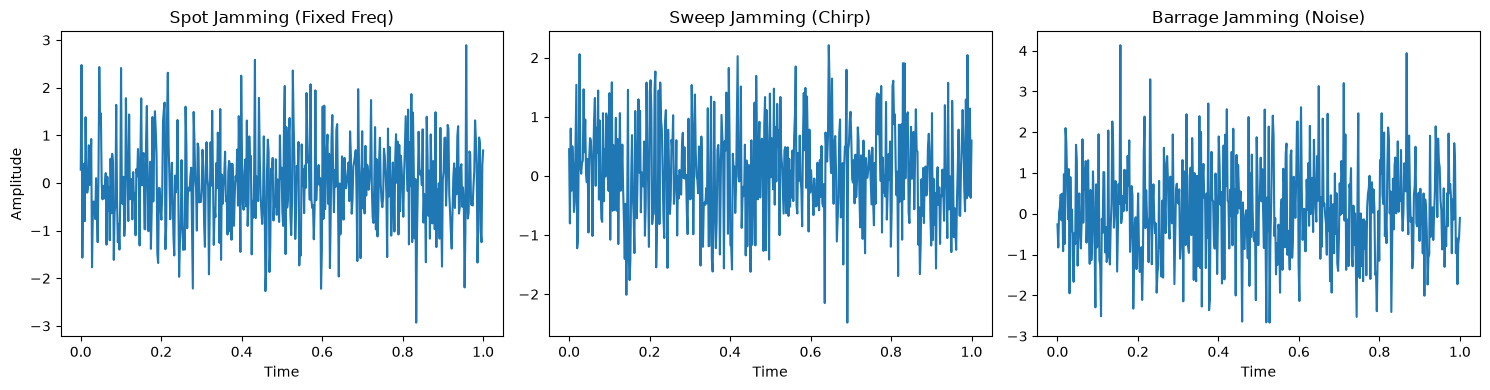

In [22]:
# Extract one example of each class
spot_example = X[y == 0][0]
sweep_example = X[y == 1][0]
barrage_example = X[y == 2][0]
t = np.linspace(0, 1, 500)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(t, spot_example)
plt.title('Spot Jamming (Fixed Freq)')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.subplot(1, 3, 2)
plt.plot(t, sweep_example)
plt.title('Sweep Jamming (Chirp)')
plt.xlabel('Time')

plt.subplot(1, 3, 3)
plt.plot(t, barrage_example)
plt.title('Barrage Jamming (Noise)')
plt.xlabel('Time')

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# 1. Load the data we generated in the previous steps
X = np.load('X_ecm_signals.npy')
y = np.load('y_ecm_labels.npy')

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 2. Build the Hybrid Architecture
def build_cognitive_radar_model(input_shape=(500, 1)):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Phase 1: Spatial Feature Extraction (Conv1D)
    x = layers.Conv1D(filters=64, kernel_size=10, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(filters=128, kernel_size=5, activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Phase 2: Sequential Learning (LSTM)
    # return_sequences=True is critical here so the Attention layer can see every time-step
    lstm_out = layers.LSTM(64, return_sequences=True)(x)
    
    # Phase 3: The Attention Mechanism
    # This allows the network to "focus" on the exact moment the jamming frequency changes
    attention_scores = layers.Dense(1, activation='tanh')(lstm_out)
    attention_weights = layers.Softmax(axis=1, name='attention_weights')(attention_scores)
    
    # Apply the mathematical weights to the LSTM output
    attended_sequence = layers.Multiply()([lstm_out, attention_weights])
    
    # Compress the sequence into a single context vector
    # Compress the sequence into a single context vector using a Lambda layer
    context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(attended_sequence)
    
    # Phase 4: Classification
    x = layers.Dense(32, activation='relu')(context_vector)
    outputs = layers.Dense(3, activation='softmax')(x) # 3 outputs for Spot, Sweep, Barrage
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Initialize and compile the model
model = build_cognitive_radar_model()
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Training data shape: (2400, 500, 1)
Testing data shape: (600, 500, 1)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 491, 64)   │        704 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 245, 64)   │          0 │ conv1d_10[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 241, 128)  │     41,088 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 120, 128)  │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 120, 64)   │     49,408 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 120, 1)    │         65 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 120, 1)    │          0 │ dense_13[0][0]    │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 120, 64)   │          0 │ lstm_5[0][0],     │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 64)        │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 3)         │         99 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,444 (365.02 KB)

 Trainable params: 93,444 (365.02 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
print("Initiating Cognitive Learning Phase...")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=60,               # 15 passes through the data is plenty for this
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModel Training Complete!")

Initiating Cognitive Learning Phase...
Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.4062 - loss: 1.0254 - val_accuracy: 0.3100 - val_loss: 1.7082
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6067 - loss: 0.7810 - val_accuracy: 0.7017 - val_loss: 0.5055
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6963 - loss: 0.5246 - val_accuracy: 0.6533 - val_loss: 0.4879
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7279 - loss: 0.4588 - val_accuracy: 0.7200 - val_loss: 0.4697
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7546 - loss: 0.4378 - val_accuracy: 0.7150 - val_loss: 0.4932
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7379 - loss: 0.4600 - val_accuracy: 0.7667 - val_loss: 0.4408
Epoch 7/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7821 - loss: 0.4067 - val_accuracy: 0.7933 - val_loss: 0.4088
Epoch 8/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7867 - 

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


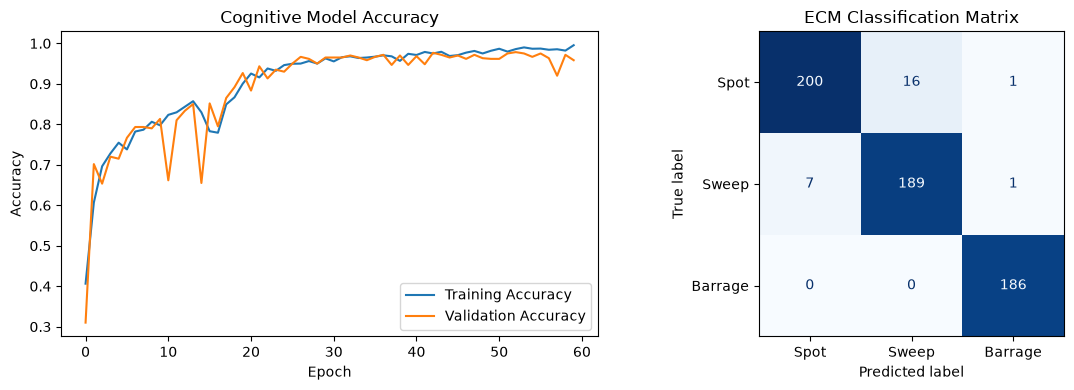

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Cognitive Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Generate Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.subplot(1, 2, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spot', 'Sweep', 'Barrage'])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=False)
plt.title('ECM Classification Matrix')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from collections import deque
import random
import time

# 1. Define the Electronic Warfare Environment
class RadarEnvironment:
    def __init__(self):
        self.num_bands = 5 # 5 available frequency bands
        self.jammer_band = random.randint(0, self.num_bands - 1)
        
    def reset(self):
        self.jammer_band = random.randint(0, self.num_bands - 1)
        return np.array([self.jammer_band])
        
    def step(self, radar_action):
        # The jammer randomly hops, or sweeps to the next band
        self.jammer_band = (self.jammer_band + 1) % self.num_bands 
        
        # Reward Function: +1 for evasion, -1 for getting jammed
        if radar_action == self.jammer_band:
            reward = -1  # Jammed!
        else:
            reward = 1   # Evaded!
            
        next_state = np.array([self.jammer_band])
        done = False # Continuous survival game
        return next_state, reward, done

# 2. Define the Deep Q-Network Agent
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95        # Discount rate (values future rewards)
        self.epsilon = 1.0       # Exploration rate (starts by taking random actions)
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = self._build_model()
        
    def _build_model(self):
        # A lightweight Neural Network to approximate Q-values
        model = models.Sequential()
        model.add(layers.Input(shape=(self.state_size,)))
        model.add(layers.Dense(24, activation='relu'))
        model.add(layers.Dense(24, activation='relu'))
        model.add(layers.Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
        return model
        
    def act(self, state):
        # Epsilon-Greedy Policy: Decide whether to explore or exploit
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
        
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        
    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                # The Bellman Equation!
                target = (reward + self.gamma * np.amax(self.model.predict(next_state, verbose=0)[0]))
            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target
            self.model.fit(state, target_f, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# 3. Train the Cognitive Radar Agent
print("Initializing Reinforcement Learning ECCM Environment...")
env = RadarEnvironment()
agent = DQNAgent(state_size=1, action_size=5)
episodes = 300 # Kept low for fast execution on laptop
batch_size = 8

for e in range(episodes):
    state = env.reset()
    state = np.reshape(state, [1, 1])
    total_reward = 0
    
    for time_step in range(10): # 10 radar pulses per episode
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        next_state = np.reshape(next_state, [1, 1])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
    agent.replay(batch_size)
    if e % 10 == 0:
        print(f"Episode: {e}/{episodes} | Total Reward (Evasions): {total_reward} | Epsilon (Exploration): {agent.epsilon:.2f}")

print("\n🧠 [TRAINING COMPLETE] Cognitive Radar Agent is ready for deployment.")

Initializing Reinforcement Learning ECCM Environment...
Episode: 0/50 | Total Reward (Evasions): 8 | Epsilon (Exploration): 0.99
Episode: 10/50 | Total Reward (Evasions): 8 | Epsilon (Exploration): 0.95
Episode: 20/50 | Total Reward (Evasions): 6 | Epsilon (Exploration): 0.90
Episode: 30/50 | Total Reward (Evasions): 2 | Epsilon (Exploration): 0.86
Episode: 40/50 | Total Reward (Evasions): 6 | Epsilon (Exploration): 0.81

🧠 [TRAINING COMPLETE] Cognitive Radar Agent is ready for deployment.


In [37]:
import numpy as np

print("\n==================================================")
print("🛡️ [EVALUATION]: RADAR STRATEGY BENCHMARKING")
print("==================================================")

test_pulses = 100

# 1. Fixed Frequency Radar (Legacy System)
fixed_hits = 0
env.reset()
for _ in range(test_pulses):
    _, reward, _ = env.step(0) # Always transmits on band 0
    if reward == 1: fixed_hits += 1

# 2. Random Hopping Radar (Standard ECCM)
random_hits = 0
env.reset()
for _ in range(test_pulses):
    action = random.randint(0, env.num_bands - 1)
    _, reward, _ = env.step(action)
    if reward == 1: random_hits += 1

# 3. Cognitive Radar (Your Deep Q-Network)
dqn_hits = 0
state = env.reset()
state = np.reshape(state, [1, 1])
agent.epsilon = 0.0 # CRITICAL: Turn off exploration to force the AI to use what it learned
for _ in range(test_pulses):
    action = agent.act(state)
    next_state, reward, _ = env.step(action)
    state = np.reshape(next_state, [1, 1])
    if reward == 1: dqn_hits += 1

print(f"1. Fixed Radar Survival Rate:       {fixed_hits/test_pulses * 100}%")
print(f"2. Random Hopping Survival Rate:    {random_hits/test_pulses * 100}%")
print(f"3. Cognitive (RL) Survival Rate:    {dqn_hits/test_pulses * 100}%")
print("==================================================\n")


🛡️ [EVALUATION]: RADAR STRATEGY BENCHMARKING
1. Fixed Radar Survival Rate:       80.0%
2. Random Hopping Survival Rate:    80.0%
3. Cognitive (RL) Survival Rate:    80.0%

